# Student Academic Risk Prediction
**Can academic and behavioral features identify students at risk of poor performance?**

This notebook trains CPU-based scikit-learn classifiers on the supplied UCI datasets,
compares their measured performance, and provides an interactive student input form.

| Outcome | Definition |
|---|---|
| Fail / at risk (`1`) | Final grade **G3 < 10 out of 20** |
| Pass (`0`) | Final grade **G3 >= 10 out of 20** |

For **Mathematics** and **Portuguese**, compare **without previous grades** against
**with G1/G2**. The result displays both probabilities, the most likely outcome, and
the strongest individual input contribution. G3 is used **only to construct labels**.

**Run:** follow `README.md`, select the project kernel, and choose **Restart Kernel and Run All**.
Training takes a few minutes on CPU. The first SHAP explanation may also take longer
while its numerical routines initialize. No CUDA, PyTorch, download, or account is needed.

The reference is Kalpana et al. (2020), *Student Performance Analysis using Machine Learning*,
[DOI: 10.35940/ijitee.F3585.049620](https://doi.org/10.35940/ijitee.F3585.049620).
This is a documented extension, rather than a claim to reproduce the paper's reported results.

The model export section saves the selected pipelines for the local website (`python app.py`).

## 1. Environment and configuration
All notebook code is self-contained. The dataset paths are relative to the project folder.
Fixed seeds, fixed candidate settings, and recorded package versions support reproducibility.

In [1]:
from pathlib import Path
from collections.abc import Mapping
from numbers import Real
from importlib.metadata import version
from html import escape
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import shap
from IPython.display import display, HTML, Markdown
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, confusion_matrix, log_loss, make_scorer,
    precision_score, recall_score, f1_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
FAILURE_THRESHOLD = 0.50
BASE_FEATURES = [
    'studytime', 'absences', 'failures', 'traveltime', 'schoolsup',
    'famsup', 'activities', 'higher', 'internet',
]
GRADE_FEATURES = ['G1', 'G2']
SUBJECT_LABELS = {'math': 'Mathematics', 'portuguese': 'Portuguese'}
MODE_LABELS = {
    'without_grades': 'Without previous grades',
    'with_grades': 'With G1 and G2',
}
FEATURE_LABELS = {
    'studytime': 'Weekly study time', 'absences': 'School absences',
    'failures': 'Past class failures', 'traveltime': 'Travel time to school',
    'schoolsup': 'Extra school support', 'famsup': 'Family educational support',
    'activities': 'Extracurricular activities', 'higher': 'Plans higher education',
    'internet': 'Internet access at home', 'G1': 'First-period grade',
    'G2': 'Second-period grade',
}
FEATURE_OPTIONS = {
    'studytime': [('<2 hours/week', 1), ('2-5 hours/week', 2),
                  ('5-10 hours/week', 3), ('>10 hours/week', 4)],
    'traveltime': [('<15 minutes', 1), ('15-30 minutes', 2),
                   ('30-60 minutes', 3), ('>60 minutes', 4)],
    'failures': [('0', 0), ('1', 1), ('2', 2), ('3', 3)],
    **{name: [('No', 'no'), ('Yes', 'yes')] for name in
       ['schoolsup', 'famsup', 'activities', 'higher', 'internet']},
}
INTEGER_RANGES = {'absences': (0, 93), 'G1': (0, 20), 'G2': (0, 20)}
CATEGORICAL_FEATURES = list(FEATURE_OPTIONS)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset' / 'student-mat.csv').exists():
    raise FileNotFoundError('Start Jupyter from the project folder containing dataset/.')

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'font.size': 10, 'figure.facecolor': 'white',
})
ENVIRONMENT = {'Python': platform.python_version(), **{
    name: version(name) for name in
    ['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'shap', 'ipywidgets']
}}
display(pd.Series(ENVIRONMENT, name='Version').to_frame())

,Version
Python,3.12.14
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
matplotlib,3.11.2
shap,0.52.0
ipywidgets,8.1.9


## 2. Data and student input domains

The datasets contain secondary-school records from two Portuguese schools, collected
through school reports and questionnaires. They describe the course outcome, not
general intelligence or a student's ability across all subjects.

Use a focused form rather than all demographic and family fields:

| Field | Accepted input |
|---|---|
| `studytime` | 1: <2 h/week; 2: 2-5 h; 3: 5-10 h; 4: >10 h |
| `absences` | Integer 0-93, the codebook range |
| `failures` | Integer category 0, 1, 2, or 3 |
| `traveltime` | 1: <15 min; 2: 15-30 min; 3: 30-60 min; 4: >60 min |
| `schoolsup`, `famsup`, `activities`, `higher`, `internet` | `yes` or `no` |
| `G1`, `G2` (grades mode only) | Integer 0-20 |

The legacy `student.txt` wording for failures mentions an `else 4` code, but these files
actually contain 0-3. We use their observed 0-3 categories, not an invented count of four.
The form's absence range follows the codebook; values beyond a model's training range
are identified in the result as less supported by the available data.

Several students appear in both subjects. **Do not concatenate the subjects or interpret
the combined record count as a count of independent students.** No student identity is inferred.

In [2]:
DATA_FILES = {'math': 'student-mat.csv', 'portuguese': 'student-por.csv'}
DATASETS = {subject: pd.read_csv(PROJECT_ROOT / 'dataset' / file, sep=';')
            for subject, file in DATA_FILES.items()}

def features_for(mode):
    if not isinstance(mode, str) or mode not in MODE_LABELS:
        raise ValueError(f"mode must be one of {list(MODE_LABELS)}; received {mode!r}.")
    return BASE_FEATURES + (GRADE_FEATURES if mode == 'with_grades' else [])

def validate_inputs(mode, inputs):
    """Return a one-row DataFrame in model order; never silently fill user inputs."""
    features = features_for(mode)
    if not isinstance(inputs, Mapping):
        raise ValueError('inputs must be a dictionary mapping field names to values.')
    missing = [name for name in features if name not in inputs]
    extra = [name for name in inputs if name not in features]
    if missing:
        raise ValueError('Missing required inputs: ' + ', '.join(missing))
    if extra:
        raise ValueError('Unexpected inputs for this mode: ' + ', '.join(map(str, extra)))
    clean = {}
    for name in features:
        value = inputs[name]
        if name in FEATURE_OPTIONS:
            allowed = [raw for _, raw in FEATURE_OPTIONS[name]]
            if isinstance(allowed[0], str):
                if not isinstance(value, str) or value not in allowed:
                    raise ValueError(f'{name} must be one of {allowed}.')
                clean[name] = value
                continue
        if (isinstance(value, (bool, np.bool_)) or not isinstance(value, Real)
                or not np.isfinite(value) or float(value) != int(value)):
            raise ValueError(f'{name} must be a finite integer.')
        value = int(value)
        if name in FEATURE_OPTIONS:
            if value not in allowed:
                raise ValueError(f'{name} must be one of {allowed}.')
        else:
            lo, hi = INTEGER_RANGES[name]
            if not lo <= value <= hi:
                raise ValueError(f'{name} must be between {lo} and {hi}, inclusive.')
        clean[name] = value
    return pd.DataFrame([clean], columns=features)

overview = []
for subject, df in DATASETS.items():
    required = BASE_FEATURES + GRADE_FEATURES + ['G3']
    assert set(required).issubset(df.columns), 'Required dataset column missing.'
    assert not df[required].isna().any().any(), 'Missing values need explicit handling.'
    assert df['G3'].between(0, 20).all()
    assert not df.duplicated().any(), 'Duplicate rows require an explicit split policy.'
    for row in df[BASE_FEATURES + GRADE_FEATURES].to_dict('records'):
        validate_inputs('with_grades', row)
    y = (df['G3'] < 10).astype(int)
    overview.append({
        'subject': SUBJECT_LABELS[subject], 'course_records': len(df),
        'fail': int(y.sum()), 'pass': int((y == 0).sum()),
        'failure_rate': y.mean(), 'missing_cells': int(df.isna().sum().sum()),
    })
overview_df = pd.DataFrame(overview).set_index('subject')
display(overview_df.style.format({'failure_rate': '{:.1%}'}))

,course_records,fail,pass,failure_rate,missing_cells
subject,,,,,
Mathematics,395,130,265,32.9%,0
Portuguese,649,100,549,15.4%,0


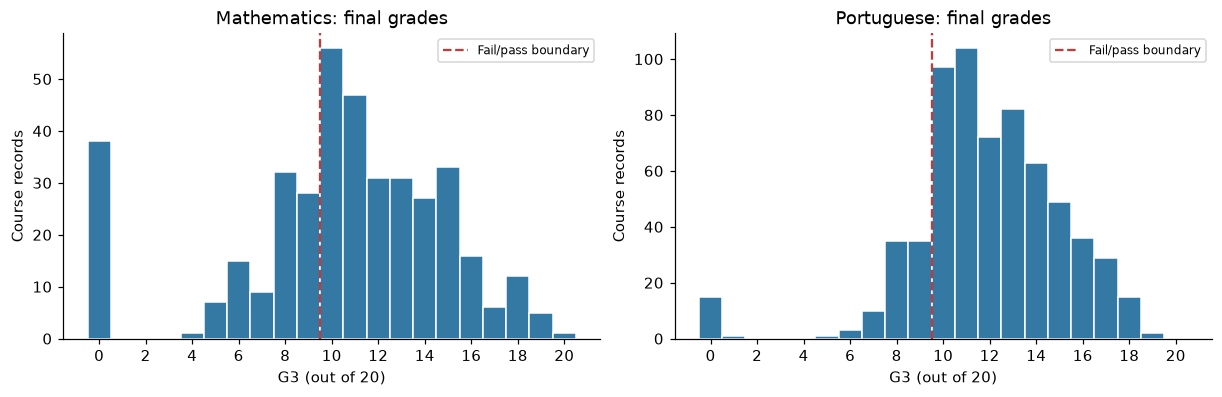

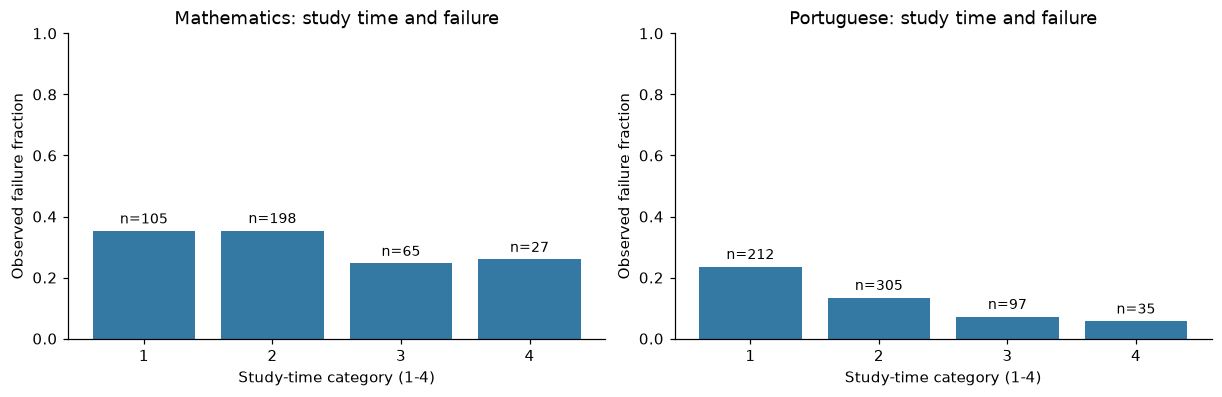

These descriptive associations are not causal effects. Candidate models and features are fixed below, independently of test results.

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for ax, (subject, df) in zip(axes, DATASETS.items()):
    ax.hist(df['G3'], bins=np.arange(-0.5, 21.5, 1), color='#3478a4', edgecolor='white')
    ax.axvline(9.5, color='#bd3d3a', linestyle='--', label='Fail/pass boundary')
    ax.set(title=f'{SUBJECT_LABELS[subject]}: final grades', xlabel='G3 (out of 20)',
           ylabel='Course records', xticks=range(0, 21, 2))
    ax.legend(fontsize=8)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for ax, (subject, df) in zip(axes, DATASETS.items()):
    summary = df.assign(fail=(df['G3'] < 10).astype(int)).groupby('studytime')['fail'].agg(['mean', 'count'])
    ax.bar(summary.index, summary['mean'], color='#3478a4')
    ax.set(title=f'{SUBJECT_LABELS[subject]}: study time and failure',
           xlabel='Study-time category (1-4)', ylabel='Observed failure fraction',
           xticks=[1, 2, 3, 4], ylim=(0, 1))
    for category, row in summary.iterrows():
        ax.text(category, row['mean'] + .025, f"n={int(row['count'])}", ha='center', fontsize=9)
plt.show()
display(Markdown('These descriptive associations are not causal effects. Candidate models and features are fixed below, independently of test results.'))

## 3. Split once, preprocess within training folds

Reserve a stratified **20% test set per subject** with seed 42. Both input modes reuse
the exact same row indices. Subjects are evaluated separately; no cross-subject metric
claims independence of their overlapping students.

Study-time, travel-time, failures, and yes/no fields are categorical. One-hot encoding
uses the declared input domains. Absences and grades are numeric and scaled inside
each pipeline. No imputation is needed: this data has no missing inputs, and the form
requires complete active fields. All learned preprocessing stays inside training folds.

In [4]:
SPLITS = {}
split_rows = []
for subject, df in DATASETS.items():
    y = (df['G3'] < 10).astype(int)
    train_ids, test_ids = train_test_split(df.index.to_numpy(), test_size=.20,
                                         stratify=y, random_state=SEED)
    SPLITS[subject] = {'train': train_ids, 'test': test_ids}
    assert set(train_ids).isdisjoint(test_ids)
    assert len(train_ids) + len(test_ids) == len(df)
    split_rows.append({'subject': SUBJECT_LABELS[subject], 'train': len(train_ids),
                       'test': len(test_ids), 'test_fail': int(y.loc[test_ids].sum())})
display(pd.DataFrame(split_rows).set_index('subject'))

def make_preprocessor(features):
    categorical = [f for f in features if f in CATEGORICAL_FEATURES]
    numeric = [f for f in features if f not in categorical]
    categories = [[raw for _, raw in FEATURE_OPTIONS[f]] for f in categorical]
    return ColumnTransformer([
        ('numeric', StandardScaler(), numeric),
        ('categorical', OneHotEncoder(categories=categories, handle_unknown='error',
                                      sparse_output=False), categorical),
    ], remainder='drop')

def candidates_for(features):
    def pipeline(estimator):
        return Pipeline([('preprocess', make_preprocessor(features)), ('model', estimator)])
    def calibrated(estimator):
        # Calibration refits the ENTIRE pipeline in each inner training fold.
        return CalibratedClassifierCV(
            estimator=pipeline(estimator), method='sigmoid', ensemble=False,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), n_jobs=1,
        )
    return {
        'prior_baseline': pipeline(DummyClassifier(strategy='prior', random_state=SEED)),
        'logistic_regression': pipeline(LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)),
        'calibrated_decision_tree': calibrated(DecisionTreeClassifier(
            max_depth=4, min_samples_leaf=8, random_state=SEED)),
        'calibrated_random_forest': calibrated(RandomForestClassifier(
            n_estimators=150, max_depth=8, min_samples_leaf=3,
            random_state=SEED, n_jobs=1)),
    }

,train,test,test_fail
subject,,,
Mathematics,316,79,26
Portuguese,519,130,20


## 4. Model comparison and selection

For each subject/mode, use the same shuffled **five-fold stratified training CV**.
Select the lowest mean validation log loss; ties at ten decimal places favor higher
failure recall, then the candidate name for deterministic ordering. The prior baseline
is eligible to win: the notebook should not force a feature model to beat the evidence.

Tree candidates use **three inner training folds for sigmoid probability calibration**,
so neither outer-validation nor test records fit their calibrator. Logistic regression
provides probabilities directly. Candidate settings are fixed; no test-driven tuning is used.
Class weights and oversampling are omitted to preserve the observed outcome prior.

In [5]:
MODEL_REGISTRY = {}
CV_ROWS = []
start = time.perf_counter()
scoring = {
    'neg_log_loss': 'neg_log_loss',
    'failure_recall': make_scorer(recall_score, pos_label=1, zero_division=0),
}
for subject, df in DATASETS.items():
    train_ids = SPLITS[subject]['train']
    y_train = (df.loc[train_ids, 'G3'] < 10).astype(int)
    for mode in MODE_LABELS:
        features = features_for(mode)
        assert 'G3' not in features
        X_train = df.loc[train_ids, features]
        candidates = candidates_for(features)
        local_rows = []
        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        for name, estimator in candidates.items():
            result = cross_validate(estimator, X_train, y_train, cv=outer_cv,
                                    scoring=scoring, n_jobs=1, error_score='raise')
            losses = -result['test_neg_log_loss']
            row = {'subject': subject, 'mode': mode, 'candidate': name,
                   'cv_log_loss': float(losses.mean()),
                   'cv_log_loss_sd': float(losses.std(ddof=1)),
                   'cv_failure_recall': float(result['test_failure_recall'].mean())}
            local_rows.append(row)
            CV_ROWS.append(row)
        winner = sorted(local_rows, key=lambda r: (
            round(r['cv_log_loss'], 10), -r['cv_failure_recall'], r['candidate']))[0]
        selected = clone(candidates[winner['candidate']]).fit(X_train, y_train)
        baseline = clone(candidates['prior_baseline']).fit(X_train, y_train)
        MODEL_REGISTRY[(subject, mode)] = {
            'estimator': selected, 'baseline': baseline, 'model_name': winner['candidate'],
            'features': features, 'train_ids': train_ids.copy(),
            'test_ids': SPLITS[subject]['test'].copy(), 'selection': winner,
        }
        print(f"{SUBJECT_LABELS[subject]} | {MODE_LABELS[mode]}: "
              f"{winner['candidate']} (CV log loss {winner['cv_log_loss']:.3f})")
print(f'Training completed in {time.perf_counter() - start:.1f} seconds on CPU.')
cv_results = pd.DataFrame(CV_ROWS)
cv_results['selected'] = cv_results.apply(
    lambda r: MODEL_REGISTRY[(r['subject'], r['mode'])]['model_name'] == r['candidate'], axis=1)
display(cv_results.sort_values(['subject', 'mode', 'cv_log_loss']).reset_index(drop=True)
        .style.format({c: '{:.4f}' for c in ['cv_log_loss', 'cv_log_loss_sd', 'cv_failure_recall']}))

Mathematics | Without previous grades: calibrated_random_forest (CV log loss 0.583)


Mathematics | With G1 and G2: calibrated_random_forest (CV log loss 0.221)


Portuguese | Without previous grades: logistic_regression (CV log loss 0.367)


Portuguese | With G1 and G2: logistic_regression (CV log loss 0.163)
Training completed in 23.7 seconds on CPU.


,subject,mode,candidate,cv_log_loss,cv_log_loss_sd,cv_failure_recall,selected
0,math,with_grades,calibrated_random_forest,0.2214,0.0759,0.8952,True
1,math,with_grades,logistic_regression,0.2224,0.0770,0.8090,False
2,math,with_grades,calibrated_decision_tree,0.2555,0.0862,0.8952,False
3,math,with_grades,prior_baseline,0.6336,0.0048,0.0000,False
4,math,without_grades,calibrated_random_forest,0.5825,0.0705,0.3186,True
5,math,without_grades,calibrated_decision_tree,0.5944,0.0315,0.2295,False
6,math,without_grades,logistic_regression,0.6210,0.0734,0.2410,False
7,math,without_grades,prior_baseline,0.6336,0.0048,0.0000,False
8,portuguese,with_grades,logistic_regression,0.1629,0.0598,0.6625,True
9,portuguese,with_grades,calibrated_random_forest,0.1764,0.0761,0.7375,False


## 5. Held-out evaluation

Evaluate the selected model and the prior baseline on the reserved records.
`1` always means failure. Displayed predictions use **P(fail) >= 0.50**; an exact
50/50 tie is flagged as Fail by this documented convention. Report **average precision**
as the step-weighted summary of the precision-recall curve (labeled PR average precision).

Lower log loss and Brier score are better; higher recall means fewer failing students
are missed. Accuracy alone can hide poor failure recall. Log loss and Brier score assess
overall probability quality, so also inspect reliability plots rather than equating these
scores with calibration alone. Small test sets make all these estimates uncertain.

In [6]:
def probability_map(estimator, frame):
    classes = list(estimator.classes_)
    assert set(classes) == {0, 1}, 'Model must know both outcome classes.'
    raw = np.asarray(estimator.predict_proba(frame), dtype=float)
    assert np.isfinite(raw).all() and ((raw >= 0) & (raw <= 1)).all()
    assert np.allclose(raw.sum(axis=1), 1.0, atol=1e-10)
    return {'pass': raw[:, classes.index(0)], 'fail': raw[:, classes.index(1)]}

def metric_values(y_true, p_fail):
    predicted = (p_fail >= FAILURE_THRESHOLD).astype(int)
    return {
        'log_loss': log_loss(y_true, np.column_stack([1 - p_fail, p_fail]), labels=[0, 1]),
        'brier_score': brier_score_loss(y_true, p_fail),
        'failure_precision': precision_score(y_true, predicted, zero_division=0),
        'failure_recall': recall_score(y_true, predicted, zero_division=0),
        'failure_f1': f1_score(y_true, predicted, zero_division=0),
        'roc_auc': roc_auc_score(y_true, p_fail),
        'pr_average_precision': average_precision_score(y_true, p_fail),
        'accuracy': accuracy_score(y_true, predicted),
    }

TEST_ROWS = []
TEST_PREDICTIONS = {}
for (subject, mode), bundle in MODEL_REGISTRY.items():
    df = DATASETS[subject]
    ids = bundle['test_ids']
    X_test = df.loc[ids, bundle['features']]
    y_test = (df.loc[ids, 'G3'] < 10).astype(int)
    for role in ['selected', 'baseline']:
        estimator = bundle['estimator'] if role == 'selected' else bundle['baseline']
        p_fail = probability_map(estimator, X_test)['fail']
        TEST_ROWS.append({'subject': subject, 'mode': mode, 'role': role,
                          'model': bundle['model_name'] if role == 'selected' else 'prior_baseline',
                          'test_records': len(ids), **metric_values(y_test, p_fail)})
        TEST_PREDICTIONS[(subject, mode, role)] = (y_test.to_numpy(), p_fail)
test_results = pd.DataFrame(TEST_ROWS)
metric_columns = list(metric_values(np.array([0, 1]), np.array([.25, .75])))
display(test_results.style.format({c: '{:.3f}' for c in metric_columns}))

,subject,mode,role,model,test_records,log_loss,brier_score,failure_precision,failure_recall,failure_f1,roc_auc,pr_average_precision,accuracy
0,math,without_grades,selected,calibrated_random_forest,79,0.563,0.190,0.615,0.308,0.410,0.747,0.585,0.709
1,math,without_grades,baseline,prior_baseline,79,0.634,0.221,0.000,0.000,0.000,0.500,0.329,0.671
2,math,with_grades,selected,calibrated_random_forest,79,0.225,0.067,0.885,0.885,0.885,0.972,0.954,0.924
3,math,with_grades,baseline,prior_baseline,79,0.634,0.221,0.000,0.000,0.000,0.500,0.329,0.671
4,portuguese,without_grades,selected,logistic_regression,130,0.395,0.123,0.333,0.100,0.154,0.735,0.359,0.831
5,portuguese,without_grades,baseline,prior_baseline,130,0.429,0.130,0.000,0.000,0.000,0.500,0.154,0.846
6,portuguese,with_grades,selected,logistic_regression,130,0.184,0.049,0.783,0.900,0.837,0.955,0.893,0.946
7,portuguese,with_grades,baseline,prior_baseline,130,0.429,0.130,0.000,0.000,0.000,0.500,0.154,0.846


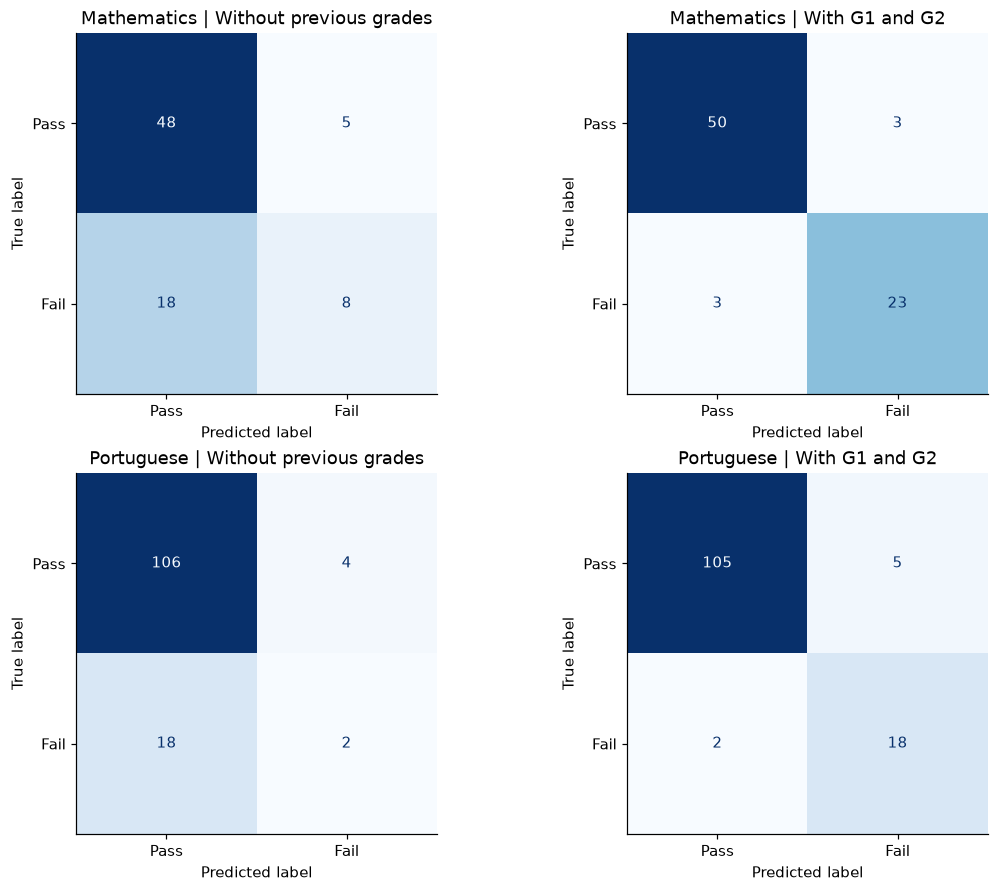

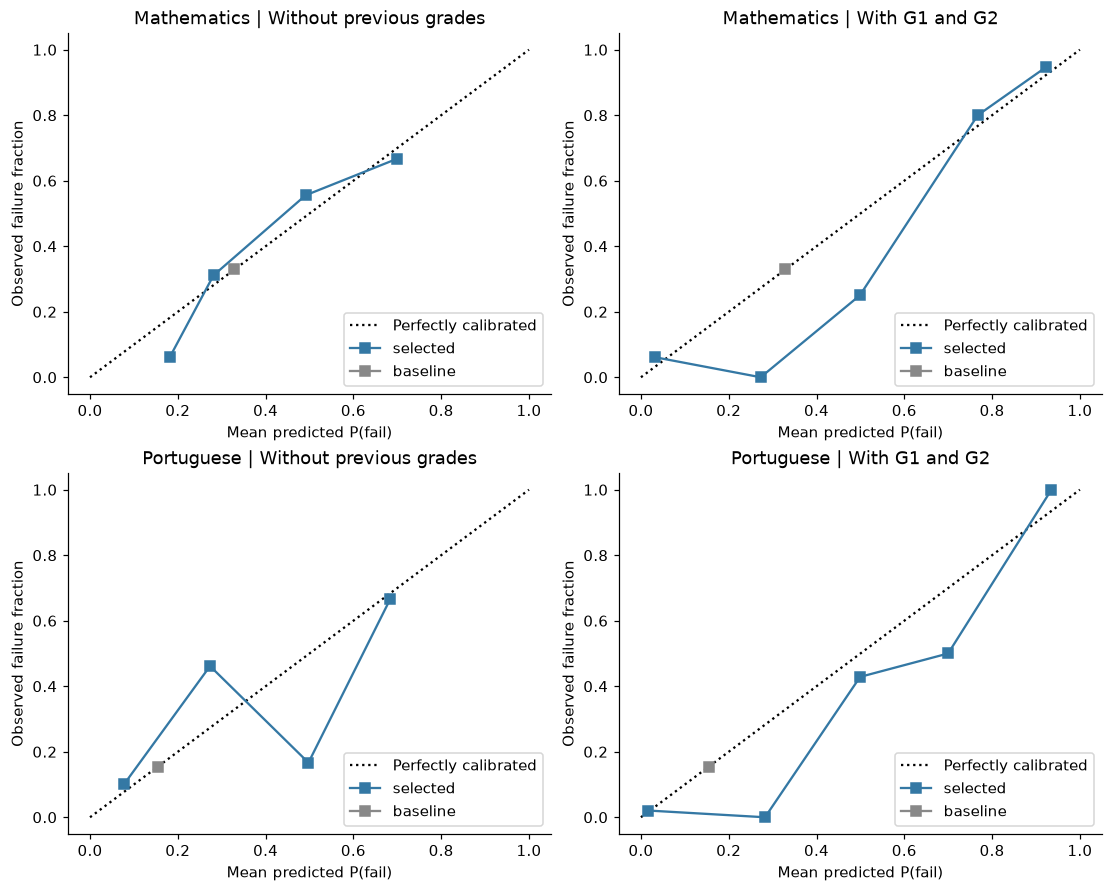

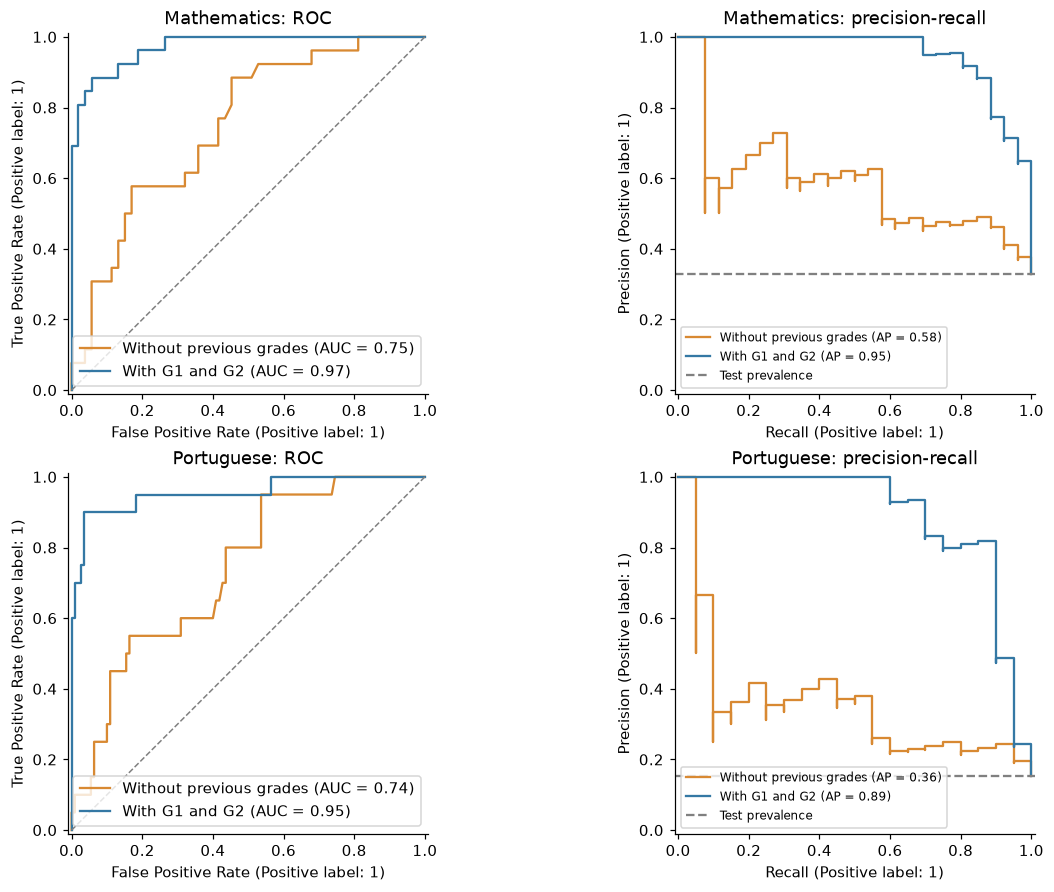

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, ((subject, mode), bundle) in zip(axes.flat, MODEL_REGISTRY.items()):
    y_true, p = TEST_PREDICTIONS[(subject, mode, 'selected')]
    cm = confusion_matrix(y_true, (p >= FAILURE_THRESHOLD).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Pass', 'Fail']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{SUBJECT_LABELS[subject]} | {MODE_LABELS[mode]}')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (subject, mode) in zip(axes.flat, MODEL_REGISTRY):
    for role, color in [('selected', '#3478a4'), ('baseline', '#888888')]:
        y_true, p = TEST_PREDICTIONS[(subject, mode, role)]
        CalibrationDisplay.from_predictions(y_true, p, n_bins=5, strategy='uniform',
                                            name=role, ax=ax, color=color)
    ax.set(title=f'{SUBJECT_LABELS[subject]} | {MODE_LABELS[mode]}',
           xlabel='Mean predicted P(fail)', ylabel='Observed failure fraction')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for row_index, subject in enumerate(SUBJECT_LABELS):
    for mode, color in [('without_grades', '#d88932'), ('with_grades', '#3478a4')]:
        y_true, p = TEST_PREDICTIONS[(subject, mode, 'selected')]
        RocCurveDisplay.from_predictions(y_true, p, name=MODE_LABELS[mode],
                                         ax=axes[row_index, 0], curve_kwargs={'color': color})
        PrecisionRecallDisplay.from_predictions(y_true, p, name=MODE_LABELS[mode],
                                                ax=axes[row_index, 1], curve_kwargs={'color': color})
    axes[row_index, 0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    axes[row_index, 0].set_title(f'{SUBJECT_LABELS[subject]}: ROC')
    prevalence = TEST_PREDICTIONS[(subject, 'without_grades', 'selected')][0].mean()
    axes[row_index, 1].axhline(prevalence, linestyle='--', color='gray', label='Test prevalence')
    axes[row_index, 1].set_title(f'{SUBJECT_LABELS[subject]}: precision-recall')
    axes[row_index, 1].legend(fontsize=8)
plt.show()

In [8]:
selected_results = test_results[test_results['role'] == 'selected'].set_index(['subject', 'mode'])
for subject in SUBJECT_LABELS:
    a = selected_results.loc[(subject, 'without_grades')]
    b = selected_results.loc[(subject, 'with_grades')]
    change = b['log_loss'] - a['log_loss']
    direction = 'lower' if change < 0 else 'higher' if change > 0 else 'unchanged'
    display(Markdown(
        f"**{SUBJECT_LABELS[subject]}:** held-out log loss without grades is "
        f"**{a['log_loss']:.3f}**, versus **{b['log_loss']:.3f}** with grades "
        f"({direction}; difference {change:+.3f}). Failure recall is "
        f"**{a['failure_recall']:.1%}** versus **{b['failure_recall']:.1%}**."
    ))
    baseline = test_results[(test_results['subject'] == subject)
                            & (test_results['mode'] == 'without_grades')
                            & (test_results['role'] == 'baseline')].iloc[0]
    evidence = 'improves' if a['log_loss'] < baseline['log_loss'] else 'does not improve'
    display(Markdown(
        f"The no-grades model **{evidence} probability log loss over the prior baseline** "
        f"({a['log_loss']:.3f} versus {baseline['log_loss']:.3f}). At the fixed 50% threshold, "
        f"it misses **{1-a['failure_recall']:.1%}** of the failing test records. "
        'Probability ranking and reliable identification at a chosen threshold are different goals.'
    ))
display(Markdown('These comparisons describe this fixed split. They are not a guarantee of performance on a new school or a statistical significance claim.'))

**Mathematics:** held-out log loss without grades is **0.563**, versus **0.225** with grades (lower; difference -0.337). Failure recall is **30.8%** versus **88.5%**.

The no-grades model **improves probability log loss over the prior baseline** (0.563 versus 0.634). At the fixed 50% threshold, it misses **69.2%** of the failing test records. Probability ranking and reliable identification at a chosen threshold are different goals.

**Portuguese:** held-out log loss without grades is **0.395**, versus **0.184** with grades (lower; difference -0.211). Failure recall is **10.0%** versus **90.0%**.

The no-grades model **improves probability log loss over the prior baseline** (0.395 versus 0.429). At the fixed 50% threshold, it misses **90.0%** of the failing test records. Probability ranking and reliable identification at a chosen threshold are different goals.

These comparisons describe this fixed split. They are not a guarantee of performance on a new school or a statistical significance claim.

## 6. Explain an individual prediction

Use SHAP's model-agnostic **PermutationExplainer** to explain the selected model's
**failure probability**, including any fitted calibration. Positive contributions raise
estimated failure risk relative to the background; negative contributions lower it.
Contributions are reported in **percentage points**, not relative percentages.

Each explainer uses 30 seeded **training-only** background records and 20 forward/reverse
permutation cycles. Yes/no values are temporarily coded 0/1 for masking and decoded before
prediction. Original input fields are masked together, so explanations never create invalid
one-hot categories. All masked field values come from valid student or training inputs.

SHAP estimates contributions and reconciles them with the predicted probability; finite
sampling can change rankings of similarly influential features. Background masking can
combine fields from different records, so these are model explanations, not causal
estimates or proof that changing a feature will improve a student's grade.

In [9]:
EXPLAINER_CACHE = {}
EXPLANATION_SEED = 42
BACKGROUND_SIZE = 30
PERMUTATION_CYCLES = 20

def encode_for_explanation(frame):
    encoded = frame.copy()
    for column in encoded.columns:
        if column in FEATURE_OPTIONS and isinstance(FEATURE_OPTIONS[column][0][1], str):
            encoded[column] = encoded[column].map({'no': 0, 'yes': 1})
    return encoded.to_numpy(dtype=float)

def decode_for_prediction(matrix, features):
    frame = pd.DataFrame(np.asarray(matrix, dtype=float), columns=features)
    for column in features:
        if column in FEATURE_OPTIONS and isinstance(FEATURE_OPTIONS[column][0][1], str):
            if not frame[column].isin([0, 1]).all():
                raise ValueError(f'Explanation generated an invalid category for {column}.')
            frame[column] = frame[column].map({0: 'no', 1: 'yes'})
        else:
            if not np.isfinite(frame[column]).all() or not (frame[column] == np.floor(frame[column])).all():
                raise ValueError(f'Explanation generated a noninteger value for {column}.')
            frame[column] = frame[column].astype(int)
            if column in FEATURE_OPTIONS:
                allowed = [raw for _, raw in FEATURE_OPTIONS[column]]
                if not frame[column].isin(allowed).all():
                    raise ValueError(f'Explanation generated an invalid category for {column}.')
            else:
                lo, hi = INTEGER_RANGES[column]
                if not frame[column].between(lo, hi).all():
                    raise ValueError(f'Explanation generated an out-of-range value for {column}.')
    return frame

def explainer_for(subject, mode):
    key = (subject, mode)
    if key not in EXPLAINER_CACHE:
        bundle = MODEL_REGISTRY[key]
        features = bundle['features']
        training = DATASETS[subject].loc[bundle['train_ids'], features]
        background_frame = training.sample(n=min(BACKGROUND_SIZE, len(training)), random_state=SEED)
        background = encode_for_explanation(background_frame)
        def model_function(matrix):
            decoded = decode_for_prediction(matrix, features)
            return probability_map(bundle['estimator'], decoded)['fail']
        masker = shap.maskers.Independent(background, max_samples=BACKGROUND_SIZE)
        EXPLAINER_CACHE[key] = {
            'explainer': shap.PermutationExplainer(model_function, masker,
                                                  feature_names=features, seed=EXPLANATION_SEED),
            'background_ids': background_frame.index.to_numpy(),
            'expected_probability': float(model_function(background).mean()),
        }
    return EXPLAINER_CACHE[key]

def direction_for(value):
    if abs(value) < 1e-10:
        return 'no measurable contribution'
    return 'raises failure risk' if value > 0 else 'lowers failure risk'

def predict_student(subject, mode, inputs):
    """Predict a course outcome and explain P(fail); no fitting or input storage occurs."""
    if not isinstance(subject, str) or subject not in SUBJECT_LABELS:
        raise ValueError(f"subject must be one of {list(SUBJECT_LABELS)}; received {subject!r}.")
    frame = validate_inputs(mode, inputs)
    key = (subject, mode)
    if key not in MODEL_REGISTRY:
        raise RuntimeError('Run the model training cell before predicting.')
    bundle = MODEL_REGISTRY[key]
    probabilities = {label: float(p[0]) for label, p in probability_map(bundle['estimator'], frame).items()}
    entry = explainer_for(subject, mode)
    # SHAP currently samples through NumPy's global RNG. Reset it per request for
    # reproducible explanations without changing the caller's random state.
    rng_state = np.random.get_state()
    try:
        np.random.seed(EXPLANATION_SEED)
        explanation = entry['explainer'](
            encode_for_explanation(frame),
            max_evals=PERMUTATION_CYCLES * (2 * len(bundle['features']) + 1),
            silent=True,
        )
    finally:
        np.random.set_state(rng_state)
    values = np.asarray(explanation.values[0], dtype=float).reshape(-1)
    base = float(np.asarray(explanation.base_values[0]).reshape(-1)[0])
    reconstructed = base + float(values.sum())
    if not np.isclose(reconstructed, probabilities['fail'], atol=1e-6, rtol=0):
        raise RuntimeError('Explanation failed to reconcile with the predicted probability.')
    contributions = sorted([
        {'feature': name, 'label': FEATURE_LABELS[name], 'value': frame.iloc[0][name].item()
         if isinstance(frame.iloc[0][name], np.generic) else frame.iloc[0][name],
         'contribution': float(value), 'percentage_points': float(100 * value),
         'direction': direction_for(value)}
        for name, value in zip(bundle['features'], values)
    ], key=lambda item: -abs(item['contribution']))
    prominent = contributions[0] if abs(contributions[0]['contribution']) >= 1e-10 else None
    notes = []
    training = DATASETS[subject].loc[bundle['train_ids']]
    for field in ['absences'] + (GRADE_FEATURES if mode == 'with_grades' else []):
        lo, hi = int(training[field].min()), int(training[field].max())
        if not lo <= inputs[field] <= hi:
            notes.append(f'{FEATURE_LABELS[field]} is outside this model training range ({lo}-{hi}); the estimate has less data support.')
    return {
        'subject': subject, 'mode': mode, 'model': bundle['model_name'],
        'probabilities': probabilities,
        'most_likely_outcome': 'Fail' if probabilities['fail'] >= FAILURE_THRESHOLD else 'Pass',
        'is_probability_tie': bool(np.isclose(probabilities['fail'], .5, atol=1e-12, rtol=0)),
        'failure_threshold': FAILURE_THRESHOLD, 'base_failure_probability': base,
        'feature_contributions': contributions, 'prominent_factor': prominent,
        'explanation_residual': reconstructed - probabilities['fail'], 'notes': notes,
    }

## 7. Example prediction and reusable function

This illustrative profile is user input, not an assessment of a real student.
Edit the dictionary to use the callable API. Use `subject='math'` or `'portuguese'`
and `mode='without_grades'` or `'with_grades'`. Only the grades mode accepts G1/G2.

The plots show the outcome probabilities and each original field's contribution to
**P(fail)**. The outlined contribution bar is the strongest factor by absolute magnitude;
it may be protective even when the outcome is Fail, or risk-increasing when it is Pass.

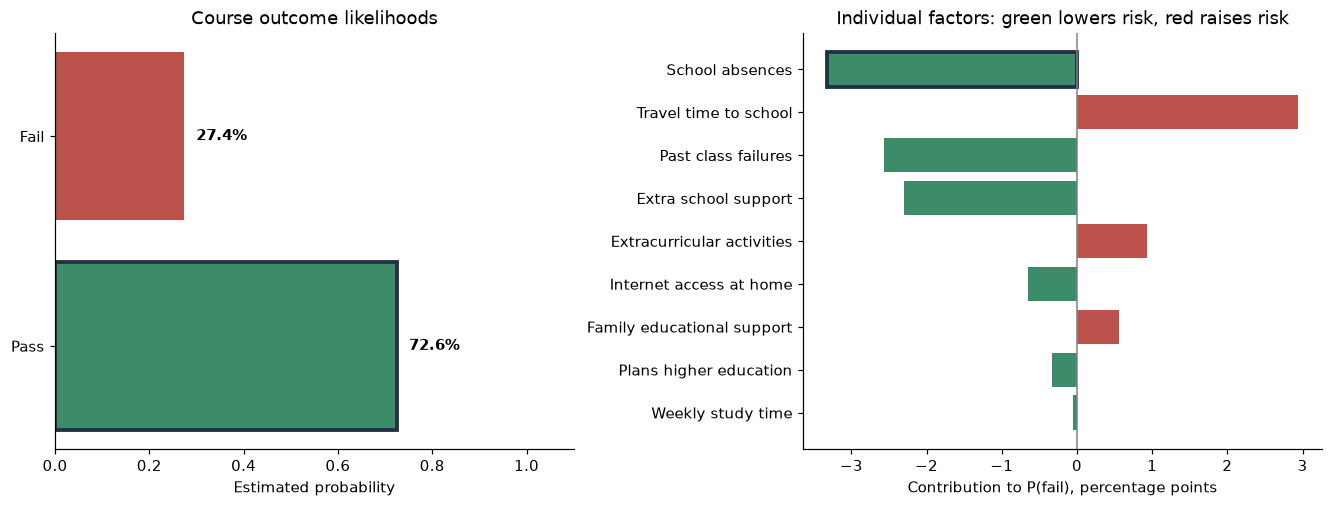

Explanation check: background P(fail) **32.2%** + contributions **-4.80 pp** = student P(fail) **27.4%**.

In [10]:
def input_value_label(feature, value):
    if feature in FEATURE_OPTIONS:
        return dict((raw, label) for label, raw in FEATURE_OPTIONS[feature])[value]
    return str(value)

def prediction_card(result):
    outcome = result['most_likely_outcome']
    color = '#a53734' if outcome == 'Fail' else '#24684a'
    factor = result['prominent_factor']
    if factor is None:
        factor_text = 'No input factor has a measurable contribution; this model predicts the prior probability.'
    else:
        factor_text = (f"<b>{escape(factor['label'])}</b> = "
                       f"{escape(input_value_label(factor['feature'], factor['value']))}: "
                       f"{escape(factor['direction'])} by {abs(factor['percentage_points']):.2f} percentage points "
                       'relative to the explanation background.')
    p = result['probabilities']
    notes_html = ''.join(f'<p>{escape(note)}</p>' for note in result['notes'])
    tie_text = '<p>Equal probabilities: the 50% failure threshold flags this tie as Fail.</p>' if result['is_probability_tie'] else ''
    return HTML(f"""
    <div style="border:1px solid #ccd7e2;border-left:6px solid {color};padding:18px;
                border-radius:8px;background:#f7fafc;color:#203045;max-width:1000px">
      <div style="font-size:13px">{escape(SUBJECT_LABELS[result['subject']])} | {escape(MODE_LABELS[result['mode']])}</div>
      <h3 style="color:{color};margin:8px 0">Most likely outcome: {outcome}</h3>
      <p style="font-size:18px"><b>Fail: {p['fail']:.1%}</b> &nbsp; | &nbsp; <b>Pass: {p['pass']:.1%}</b></p>
      <p><b>Strongest contributing factor:</b> {factor_text}</p>
      <p style="font-size:12px">Model: {escape(result['model'])}. Estimated probabilities, not certainty.
      Contributions explain model behavior and are not causal effects.</p>{tie_text}{notes_html}
    </div>""")

def show_prediction(result):
    display(prediction_card(result))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    p = result['probabilities']
    values = [p['fail'], p['pass']]
    bars = axes[0].barh(['Fail', 'Pass'], values, color=['#bd524c', '#3c8b69'])
    selected_index = 0 if result['most_likely_outcome'] == 'Fail' else 1
    bars[selected_index].set_edgecolor('#203045')
    bars[selected_index].set_linewidth(2.5)
    for bar, value in zip(bars, values):
        axes[0].text(min(value + .025, .92), bar.get_y() + bar.get_height()/2,
                     f'{value:.1%}', va='center', fontweight='bold')
    axes[0].set(xlim=(0, 1.1), xlabel='Estimated probability', title='Course outcome likelihoods')
    axes[0].invert_yaxis()
    ranked = result['feature_contributions'][::-1]
    contribution_bars = axes[1].barh(
        [c['label'] for c in ranked], [c['percentage_points'] for c in ranked],
        color=['#bd524c' if c['contribution'] > 0 else '#3c8b69' for c in ranked])
    if result['prominent_factor'] is not None:
        contribution_bars[-1].set_edgecolor('#203045')
        contribution_bars[-1].set_linewidth(2.5)
    axes[1].axvline(0, color='gray', linewidth=1)
    axes[1].set(xlabel='Contribution to P(fail), percentage points',
                title='Individual factors: green lowers risk, red raises risk')
    plt.show()
    display(Markdown(
        f"Explanation check: background P(fail) **{result['base_failure_probability']:.1%}** "
        f"+ contributions **{sum(c['percentage_points'] for c in result['feature_contributions']):+.2f} pp** "
        f"= student P(fail) **{result['probabilities']['fail']:.1%}**."
    ))

EXAMPLE_INPUTS = {
    'studytime': 2, 'absences': 6, 'failures': 0, 'traveltime': 2,
    'schoolsup': 'no', 'famsup': 'yes', 'activities': 'yes',
    'higher': 'yes', 'internet': 'yes',
}
example_result = predict_student('math', 'without_grades', EXAMPLE_INPUTS)
show_prediction(example_result)

## 8. Interactive student form

Choose the subject and input mode, enter your answers, and click **Predict**.
G1/G2 appear only in the grades mode. Every dropdown starts with **Select...** and
every numeric field starts blank, so a result cannot silently use default student details.
The prediction function does not submit responses or write student records to files.
Jupyter can preserve widget values when saving widget state; clear inputs before saving
or sharing a notebook containing real student responses.

The form requires a live Jupyter kernel. GitHub and static HTML previews show saved
analysis and example results but cannot run the Predict button.

In [11]:
FIELD_WIDGETS = {}
widget_style = {'description_width': 'initial'}
field_layout = {'width': '440px', 'max_width': '100%'}
for field in BASE_FEATURES + GRADE_FEATURES:
    if field in FEATURE_OPTIONS:
        FIELD_WIDGETS[field] = widgets.Dropdown(
            options=[('Select...', None)] + FEATURE_OPTIONS[field], value=None,
            description=FEATURE_LABELS[field], style=widget_style, layout=field_layout)
    else:
        lo, hi = INTEGER_RANGES[field]
        FIELD_WIDGETS[field] = widgets.Text(
            value='', placeholder=f'Whole number {lo}-{hi}',
            description=FEATURE_LABELS[field], style=widget_style, layout=field_layout)

subject_selector = widgets.Dropdown(
    options=[(label, key) for key, label in SUBJECT_LABELS.items()], value='math',
    description='Subject', style=widget_style, layout=field_layout)
mode_selector = widgets.Dropdown(
    options=[(label, key) for key, label in MODE_LABELS.items()], value='without_grades',
    description='Prediction mode', style=widget_style, layout=field_layout)
predict_button = widgets.Button(description='Predict', button_style='primary', icon='check')
clear_button = widgets.Button(description='Clear inputs', icon='refresh')
form_status = widgets.HTML()
form_output = widgets.Output(layout=widgets.Layout(width='100%'))
LAST_FORM_RESULT = None

def update_grade_fields(change=None):
    visible = mode_selector.value == 'with_grades'
    for field in GRADE_FEATURES:
        FIELD_WIDGETS[field].layout.display = '' if visible else 'none'
    # Never leave an old prediction visible under different selectors.
    form_output.clear_output(wait=False)
    form_status.value = ''

def collect_form_inputs(mode):
    values = {}
    missing = []
    for field in features_for(mode):
        raw = FIELD_WIDGETS[field].value
        if raw is None or (isinstance(raw, str) and not raw.strip()):
            missing.append(FEATURE_LABELS[field])
            continue
        if field in INTEGER_RANGES:
            try:
                raw = int(raw.strip())
            except ValueError:
                raise ValueError(f'{FEATURE_LABELS[field]} must be a whole number.') from None
        values[field] = raw
    if missing:
        raise ValueError('Complete these fields: ' + ', '.join(missing))
    return validate_inputs(mode, values).iloc[0].to_dict()

def clear_stale_result(change=None):
    global LAST_FORM_RESULT
    LAST_FORM_RESULT = None
    form_output.clear_output(wait=False)
    form_status.value = ''

def on_predict_clicked(button):
    global LAST_FORM_RESULT
    predict_button.disabled = True
    form_output.clear_output(wait=False)
    LAST_FORM_RESULT = None
    form_status.value = '<p>Calculating probabilities and individual contributions...</p>'
    try:
        result = predict_student(subject_selector.value, mode_selector.value,
                                 collect_form_inputs(mode_selector.value))
        LAST_FORM_RESULT = result
        with form_output:
            show_prediction(result)
        form_status.value = ''
    except ValueError as exc:
        form_status.value = f'<p style="color:#a53734"><b>Check inputs:</b> {escape(str(exc))}</p>'
    except Exception as exc:
        form_status.value = f'<p style="color:#a53734"><b>Prediction failed:</b> {escape(str(exc))}. Check that all notebook cells ran successfully.</p>'
    finally:
        predict_button.disabled = False

def on_clear_clicked(button):
    global LAST_FORM_RESULT
    for field, widget in FIELD_WIDGETS.items():
        widget.value = None if field in FEATURE_OPTIONS else ''
    LAST_FORM_RESULT = None
    clear_stale_result()

mode_selector.observe(update_grade_fields, names='value')
subject_selector.observe(clear_stale_result, names='value')
for widget in FIELD_WIDGETS.values():
    widget.observe(clear_stale_result, names='value')
predict_button.on_click(on_predict_clicked)
clear_button.on_click(on_clear_clicked)
update_grade_fields()
student_form = widgets.VBox([
    widgets.HTML('<h3>Student academic risk estimate</h3><p>Answer every active field. Grades are out of 20.</p>'),
    subject_selector, mode_selector,
    widgets.VBox([FIELD_WIDGETS[f] for f in BASE_FEATURES + GRADE_FEATURES]),
    widgets.HBox([predict_button, clear_button]), form_status, form_output,
])
display(student_form)

## 9. Verification

These checks exercise all four models, probability class ordering, invalid inputs,
training/test separation, explanation additivity, strongest-factor ranking, and the
actual widget callback. They do not claim that model explanations are causal or that
a fixed accuracy target has been achieved. The form is returned to an empty state afterward.

In [12]:
VERIFICATION_ROWS = []
for (subject, mode), bundle in MODEL_REGISTRY.items():
    assert bundle['features'] == features_for(mode)
    assert 'G3' not in bundle['features']
    if mode == 'without_grades':
        assert not set(GRADE_FEATURES).intersection(bundle['features'])
    assert np.array_equal(bundle['train_ids'], SPLITS[subject]['train'])
    assert np.array_equal(bundle['test_ids'], SPLITS[subject]['test'])
    assert set(bundle['train_ids']).isdisjoint(bundle['test_ids'])
    inputs = dict(EXAMPLE_INPUTS)
    if mode == 'with_grades':
        inputs.update(G1=8, G2=9)
    result = predict_student(subject, mode, inputs)
    assert np.isclose(sum(result['probabilities'].values()), 1.0)
    expected_outcome = 'Fail' if result['probabilities']['fail'] >= .5 else 'Pass'
    assert result['most_likely_outcome'] == expected_outcome
    prominent = result['prominent_factor']
    if prominent:
        assert abs(prominent['contribution']) == max(abs(c['contribution']) for c in result['feature_contributions'])
        assert prominent['direction'] == direction_for(prominent['contribution'])
    cached = EXPLAINER_CACHE[(subject, mode)]
    assert set(cached['background_ids']).issubset(bundle['train_ids'])
    assert set(cached['background_ids']).isdisjoint(bundle['test_ids'])
    assert np.isclose(result['base_failure_probability'], cached['expected_probability'], atol=1e-6)
    assert abs(result['explanation_residual']) < 1e-6
    # Explain a held-out record too, not only the illustrative dictionary.
    heldout_inputs = DATASETS[subject].loc[bundle['test_ids'][0], bundle['features']].to_dict()
    heldout_result = predict_student(subject, mode, heldout_inputs)
    assert abs(heldout_result['explanation_residual']) < 1e-6
    VERIFICATION_ROWS.append({'subject': subject, 'mode': mode,
                              'probability_checks': 'passed', 'explanation_checks': 'passed'})

class ReversedClassEstimator:
    classes_ = np.array([1, 0])
    def predict_proba(self, frame):
        return np.tile([.8, .2], (len(frame), 1))
mapped = probability_map(ReversedClassEstimator(), pd.DataFrame({'x': [1]}))
assert mapped['fail'][0] == .8 and mapped['pass'][0] == .2

invalid_cases = [
    ('missing input', {k: v for k, v in EXAMPLE_INPUTS.items() if k != 'studytime'}),
    ('invalid yes/no', {**EXAMPLE_INPUTS, 'internet': 'maybe'}),
    ('invalid study category', {**EXAMPLE_INPUTS, 'studytime': 0}),
    ('negative absences', {**EXAMPLE_INPUTS, 'absences': -1}),
    ('too many absences', {**EXAMPLE_INPUTS, 'absences': 94}),
    ('fractional absences', {**EXAMPLE_INPUTS, 'absences': 2.5}),
    ('NaN', {**EXAMPLE_INPUTS, 'absences': np.nan}),
    ('infinite value', {**EXAMPLE_INPUTS, 'absences': np.inf}),
    ('boolean numeric', {**EXAMPLE_INPUTS, 'absences': True}),
    ('legacy failure code', {**EXAMPLE_INPUTS, 'failures': 4}),
    ('forbidden target', {**EXAMPLE_INPUTS, 'G3': 10}),
    ('grades in wrong mode', {**EXAMPLE_INPUTS, 'G1': 10, 'G2': 10}),
]
for name, bad_inputs in invalid_cases:
    try:
        predict_student('math', 'without_grades', bad_inputs)
    except ValueError as exc:
        assert str(exc), 'Input errors must be readable.'
    else:
        raise AssertionError(f'Invalid input accepted: {name}')
for subject, mode, inputs in [
    ('unknown', 'without_grades', EXAMPLE_INPUTS),
    ('math', 'unknown', EXAMPLE_INPUTS),
    ('math', 'with_grades', EXAMPLE_INPUTS),
    ('math', 'with_grades', {**EXAMPLE_INPUTS, 'G1': 21, 'G2': 10}),
]:
    try:
        predict_student(subject, mode, inputs)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid selector or grade inputs accepted.')

repeated = predict_student('math', 'without_grades', EXAMPLE_INPUTS)
assert np.allclose([c['contribution'] for c in repeated['feature_contributions']],
                   [c['contribution'] for c in example_result['feature_contributions']], atol=1e-10)
edge_frame = validate_inputs('with_grades', {**EXAMPLE_INPUTS, 'absences': 93, 'G1': 0, 'G2': 20})
assert edge_frame.iloc[0]['absences'] == 93

# Exercise the same registered callback the Predict button uses.
on_clear_clicked(None)
on_predict_clicked(None)
assert LAST_FORM_RESULT is None and 'Complete these fields' in form_status.value
for subject in SUBJECT_LABELS:
    for mode in MODE_LABELS:
        subject_selector.value = subject
        mode_selector.value = mode
        assert (FIELD_WIDGETS['G1'].layout.display != 'none') == (mode == 'with_grades')
        assert all(FIELD_WIDGETS[f].layout.display != 'none' for f in BASE_FEATURES)
        assert subject_selector.layout.display != 'none' and mode_selector.layout.display != 'none'
        inputs = {**EXAMPLE_INPUTS, **({'G1': 8, 'G2': 9} if mode == 'with_grades' else {})}
        for field, value in inputs.items():
            FIELD_WIDGETS[field].value = str(value) if field in INTEGER_RANGES else value
        predict_button.click()
        assert LAST_FORM_RESULT is not None and form_status.value == ''
        assert LAST_FORM_RESULT['subject'] == subject and LAST_FORM_RESULT['mode'] == mode
        card = prediction_card(LAST_FORM_RESULT).data
        assert f"Most likely outcome: {LAST_FORM_RESULT['most_likely_outcome']}" in card
        if LAST_FORM_RESULT['prominent_factor']:
            assert escape(LAST_FORM_RESULT['prominent_factor']['label']) in card
        assert not predict_button.disabled
on_clear_clicked(None)
subject_selector.value = 'math'
mode_selector.value = 'without_grades'
display(pd.DataFrame(VERIFICATION_ROWS))
print(f'All four model combinations, {len(invalid_cases) + 4} invalid-input cases, '
      'class ordering, SHAP additivity, repeatability, and widget callbacks passed.')

,subject,mode,probability_checks,explanation_checks
0,math,without_grades,passed,passed
1,math,with_grades,passed,passed
2,portuguese,without_grades,passed,passed
3,portuguese,with_grades,passed,passed


All four model combinations, 16 invalid-input cases, class ordering, SHAP additivity, repeatability, and widget callbacks passed.


## 10. Save models for the website

Export the **already-fitted** selected pipelines, their training-only SHAP backgrounds,
and measured evaluation metadata to `models/`. The local website loads these files;
it does not train models when a student submits a form. Generated model files are
ignored by Git. Restart the website after exporting new models.

The saved artifacts are trusted project output, not uploaded files. Keep the manifest
and four joblib files together and use the recorded dependency versions.


In [13]:
from risk_app.storage import export_registry, ModelStore
from risk_app.prediction import Predictor

saved_manifest = export_registry(MODEL_REGISTRY, DATASETS, test_results, PROJECT_ROOT / 'models')
saved_predictor = Predictor(ModelStore(PROJECT_ROOT / 'models'))
for subject, mode in MODEL_REGISTRY:
    profile = {**EXAMPLE_INPUTS, **({'G1': 8, 'G2': 9} if mode == 'with_grades' else {})}
    notebook_result = predict_student(subject, mode, profile)
    loaded_result = saved_predictor.predict(subject, mode, profile)
    assert np.isclose(notebook_result['probabilities']['fail'], loaded_result['probabilities']['fail'], atol=1e-12)
    assert [c['feature'] for c in notebook_result['feature_contributions']] == [c['feature'] for c in loaded_result['feature_contributions']]
    assert np.allclose([c['contribution'] for c in notebook_result['feature_contributions']],
                       [c['contribution'] for c in loaded_result['feature_contributions']], atol=1e-10)
display(pd.DataFrame([{'model': m['id'], 'algorithm': m['model_name'],
                       'saved_file': m['filename'], 'size_kb': round(m['size_bytes'] / 1024, 1)}
                      for m in saved_manifest['models']]))
print('All four fitted models saved. Reloaded probabilities and SHAP explanations match the notebook.')


,model,algorithm,saved_file,size_kb
0,math-without_grades,calibrated_random_forest,math-without_grades.joblib,139.9
1,math-with_grades,calibrated_random_forest,math-with_grades.joblib,110.4
2,portuguese-without_grades,logistic_regression,portuguese-without_grades.joblib,3.1
3,portuguese-with_grades,logistic_regression,portuguese-with_grades.joblib,3.3


All four fitted models saved. Reloaded probabilities and SHAP explanations match the notebook.


## 11. Interpretation, limits, and references

Use the measured tables above to answer the research question. Look for improvement
over the prior baseline in probability quality **and** useful failure recall. A good ROC-AUC
does not automatically make the 50% threshold useful for finding all students who need help.

- The no-grades mode is **retrospective risk analysis**, not a validated early-warning
  system: total absences and behavioral measurements have no collection timestamps.
- The with-grades mode assumes both earlier-period grades are available before G3.
- Samples are small and come from Portuguese secondary schools. Performance on a
  different institution, country, or university population requires new validation.
- A factor that increases the model estimate is an association relative to the chosen
  background. Support variables may reflect existing difficulty, rather than cause it.
- The threshold is fixed at 50%; do not tune it using the reserved test set. A future
  intervention study would need training-only threshold selection and prospective data.
- Students shared between subjects mean subject results should not be pooled as
  independent evidence. This notebook never trains across subjects or creates a student database.

**References and attribution**

1. P. Kalpana, E. Arunmaran, S. Hanif, and T. Deebak (2020).
   *Student Performance Analysis using Machine Learning*. IJITEE, 9(6), 211-215.
   [DOI: 10.35940/ijitee.F3585.049620](https://doi.org/10.35940/ijitee.F3585.049620).
   The supplied PDF is included unchanged under its stated CC BY-NC-ND license.
2. P. Cortez (2008). *Student Performance* [Dataset]. UCI Machine Learning Repository.
   [DOI: 10.24432/C5TG7T](https://doi.org/10.24432/C5TG7T).
   Dataset license: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
   [Dataset description and codebook](https://archive.ics.uci.edu/dataset/320/student+performance).
3. scikit-learn: [Preventing leakage](https://scikit-learn.org/stable/common_pitfalls.html),
   [probability calibration](https://scikit-learn.org/stable/modules/calibration.html).
4. SHAP: [PermutationExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PermutationExplainer.html).